<a href="https://colab.research.google.com/github/syaharah/PRAKTIKUM-PEMODELAN-SIMULASI-DAN-OPTIMASI/blob/main/TUGAS_PRAKTIKUM_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Import Library yang Diperlukan**

In [30]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### **Import data berbentuk csv ke Jupyter Notebook**

In [31]:
# Membaca data CSV
data = pd.read_csv('sample_data/data_iklim - Sheet1.csv')
# Melihat 5 data pertama
print(data.head())

  precipitation max temperature min temperature         wind  \
0   22,17864727          22,579          16,226   0,98477418   
1   10,77861942          29,369         20,2985  1,054619598   
2   9,443091888          27,384           18,62  0,999835774   
3   15,51303961         21,7585         14,9085  0,922273123   
4   15,21262902          24,568          17,651  1,078517568   

  relative humidity        solar  
0       0,949216707  12,98674041  
1       0,837694214  20,63957504  
2       0,869631027  18,48553254  
3        0,95195662  9,497525996  
4       0,927156092  15,35485704  


### **Ubah nama variabel**

In [32]:
data.rename(columns={'precipitation': 'Y','max temperature': 'X1','min temperature': 'X2','wind': 'X3','relative humidity': 'X4','solar': 'X5'}, inplace=True)

# menampilkan data
print(data)

              Y       X1       X2           X3           X4           X5
0   22,17864727   22,579   16,226   0,98477418  0,949216707  12,98674041
1   10,77861942   29,369  20,2985  1,054619598  0,837694214  20,63957504
2   9,443091888   27,384    18,62  0,999835774  0,869631027  18,48553254
3   15,51303961  21,7585  14,9085  0,922273123   0,95195662  9,497525996
4   15,21262902   24,568   17,651  1,078517568  0,927156092  15,35485704
..          ...      ...      ...          ...          ...          ...
73  12,59995248    28,55   27,616  4,894644163  0,778710263   24,5863831
74  15,13280583   28,394  27,4405  5,250058221  0,782320956  24,46784926
75  10,98633383   28,297    27,32  5,626392953  0,784487412  23,70526639
76  9,758090113  28,4465  27,4975  5,078008382  0,777538741  23,12369102
77  8,621691253  28,6175   27,674  4,858509463   0,76938309  22,73527942

[78 rows x 6 columns]


### Untuk mengubah format data dari teks (string) menjadi angka (float).

Berfungsi untuk mengganti tanda koma ( , ) menjadi titik ( . ) pada seluruh data.

In [33]:
data = data.replace(',', '.', regex=True)
data = data.astype(float)

### Memebuat correlation plot untuk menyelidiki hubungan

In [34]:
# Menghitung matriks korelasi
correlation_matrix = data.corr()
print(correlation_matrix)

           Y        X1        X2        X3        X4        X5
Y   1.000000 -0.752439 -0.602791 -0.338976  0.640560 -0.636573
X1 -0.752439  1.000000  0.797165  0.449202 -0.736253  0.909192
X2 -0.602791  0.797165  1.000000  0.835801 -0.952236  0.878219
X3 -0.338976  0.449202  0.835801  1.000000 -0.760450  0.665849
X4  0.640560 -0.736253 -0.952236 -0.760450  1.000000 -0.778746
X5 -0.636573  0.909192  0.878219  0.665849 -0.778746  1.000000


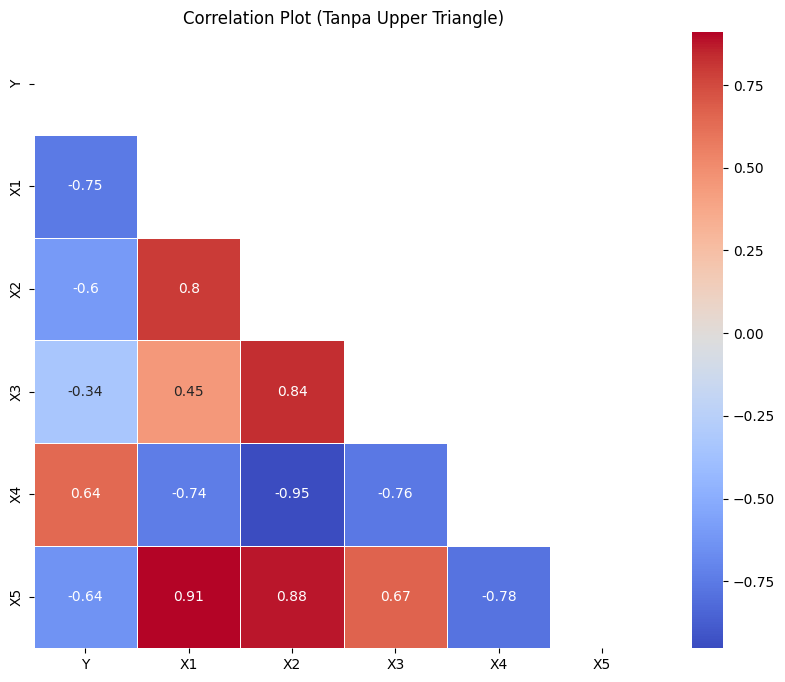

In [35]:
# Membuat mask untuk upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Membuat heatmap tanpa upper triangle
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Plot (Tanpa Upper Triangle)')
plt.show()

Heatmap membantu kita memahami hubungan antar variabel dalam dataset.

Nilai korelasi berkisar antara -1 hingga 1:

*   Mendekati +1 menunjukkan korelasi positif sempurna.
*   Mendekati 0 menunjukkan tidak ada korelasi.

*   Mendekati -1 menunjukkan korelasi negatif sempurna.

### **Interpretasi Correlation Plot**:
*   Berdasarkan correlation plot, dapat dilihat hubungan antara variabel precipitation (Y) dengan variabel independen.
*   Variabel max temperature (X1) memiliki korelasi -0,75 yang berarti hubungan negatif kuat. Artinya semakin tinggi suhu maksimum maka curah hujan cenderung menurun.
*   Variabel min temperature (X2) memiliki korelasi -0,60 yang berarti hubungan negatif sedang dengan precipitation.
*   Variabel wind (X3) memiliki korelasi -0,34 yang menunjukkan hubungan negatif lemah terhadap precipitation.
*   Variabel relative humidity (X4) memiliki korelasi 0,64 yang berarti hubungan positif cukup kuat. Artinya semakin tinggi kelembaban udara maka curah hujan cenderung meningkat.
*   Variabel solar (X5) memiliki korelasi -0,64 yang berarti hubungan negatif cukup kuat dengan precipitation.

**Kesimpulannya**, variabel yang paling berhubungan dengan precipitation adalah max temperatur(X1) dan relative humidity(X4).







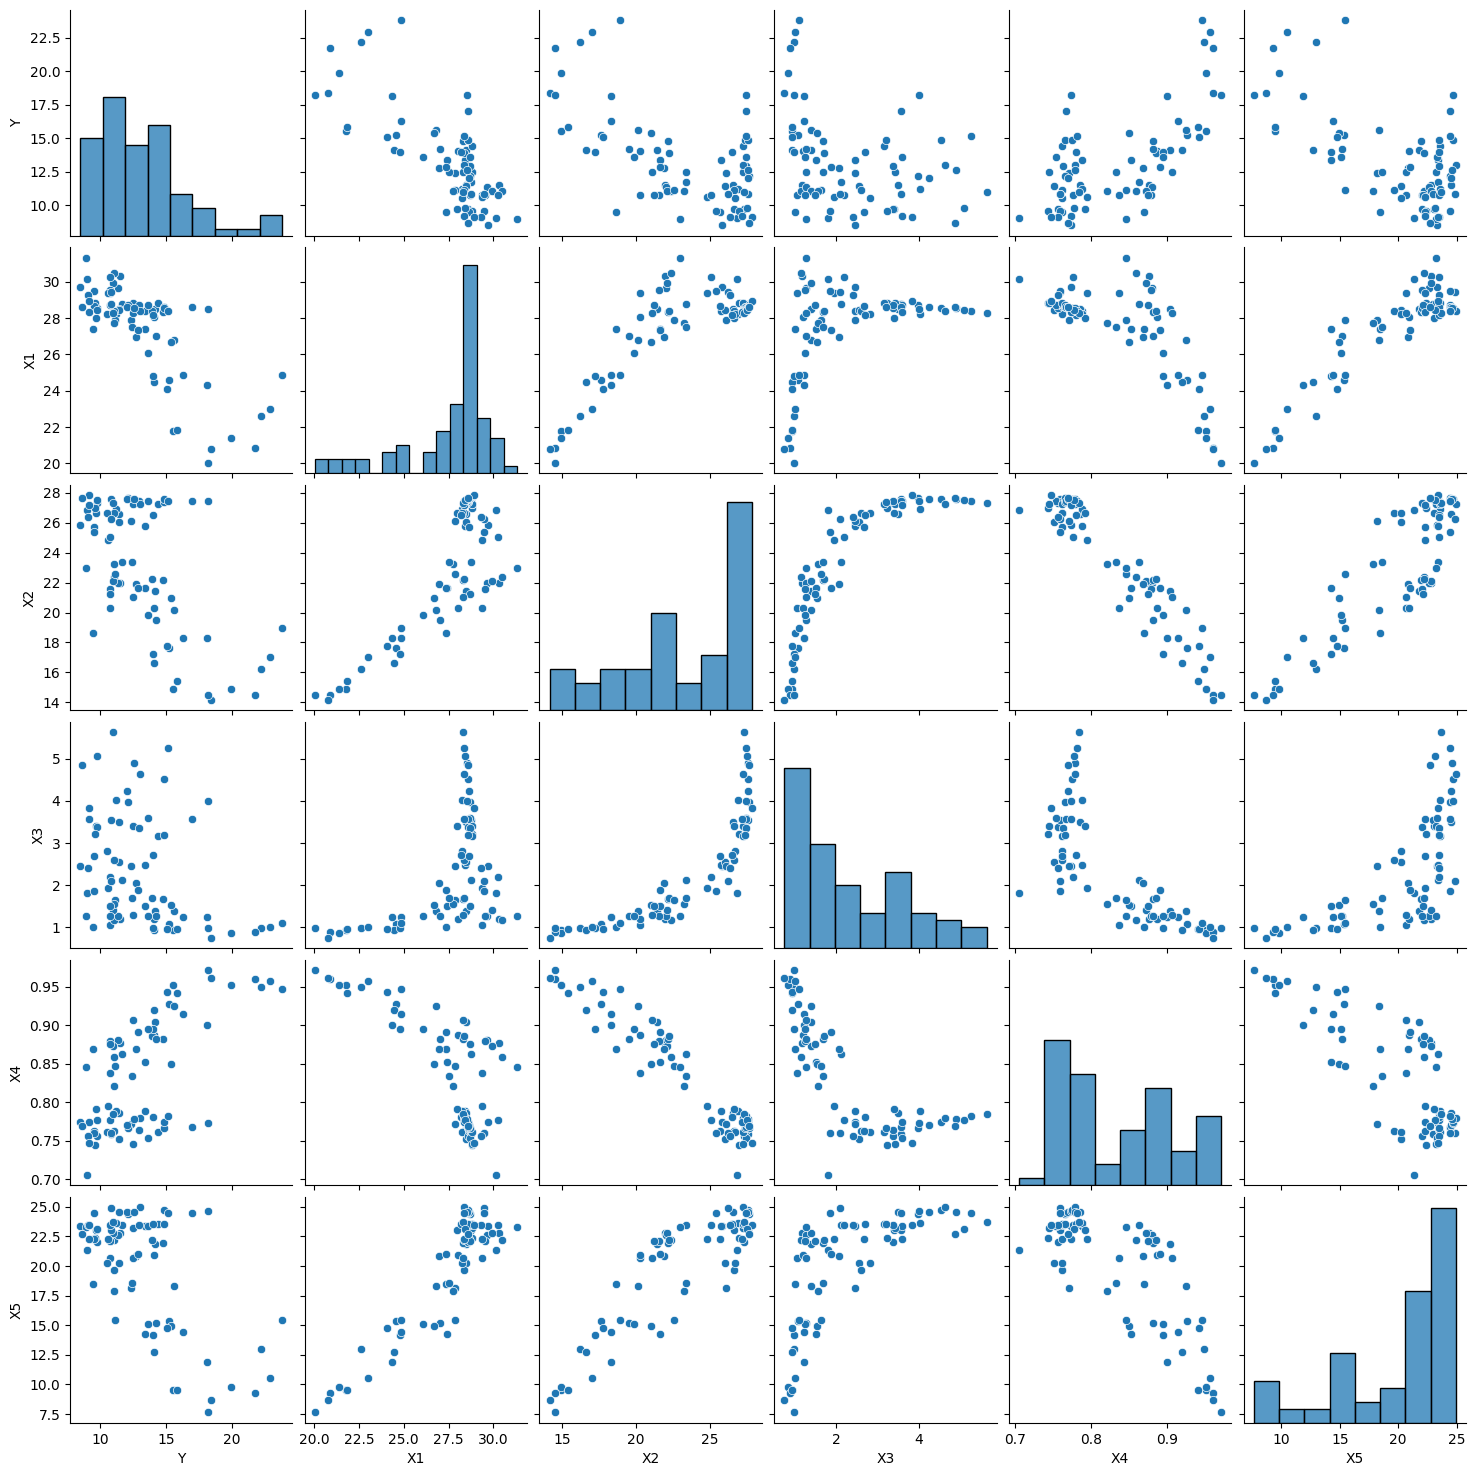

In [36]:
sns.pairplot(data)
plt.show()

###**Analisis Regresi**

**1**. **Menyelidiki deskripsi data**

In [37]:
data.describe()

,Y,X1,X2,X3,X4,X5
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,13.132865,27.490365,23.146955,2.305010,0.834104,19.934961
std,3.418236,2.500029,4.200603,1.292227,0.072323,4.813028
min,8.486084,20.026000,14.145000,0.747965,0.705405,7.636051
25%,10.784413,27.119375,20.296625,1.236886,0.769628,16.057093
50%,12.487076,28.384500,23.363250,1.871477,0.827701,22.161093
75%,14.823173,28.745500,27.144000,3.371683,0.890721,23.443735
max,23.816297,31.337000,27.852000,5.626393,0.972020,24.954589


**2. Membuat Model Regresi**


In [38]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = data[['X1','X2','X3','X4','X5']]  # Variabel independen
Y = data['Y']  # Variabel dependen

In [39]:
print(X)

         X1       X2        X3        X4         X5
0   22.5790  16.2260  0.984774  0.949217  12.986740
1   29.3690  20.2985  1.054620  0.837694  20.639575
2   27.3840  18.6200  0.999836  0.869631  18.485533
3   21.7585  14.9085  0.922273  0.951957   9.497526
4   24.5680  17.6510  1.078518  0.927156  15.354857
..      ...      ...       ...       ...        ...
73  28.5500  27.6160  4.894644  0.778710  24.586383
74  28.3940  27.4405  5.250058  0.782321  24.467849
75  28.2970  27.3200  5.626393  0.784487  23.705266
76  28.4465  27.4975  5.078008  0.777539  23.123691
77  28.6175  27.6740  4.858509  0.769383  22.735279

[78 rows x 5 columns]


In [40]:
print(Y)

0     22.178647
1     10.778619
2      9.443092
3     15.513040
4     15.212629
        ...    
73    12.599952
74    15.132806
75    10.986334
76     9.758090
77     8.621691
Name: Y, Length: 78, dtype: float64


In [41]:
# Menambahkan konstanta ke model (intercept)
X = sm.add_constant(X)

print(X)

    const       X1       X2        X3        X4         X5
0     1.0  22.5790  16.2260  0.984774  0.949217  12.986740
1     1.0  29.3690  20.2985  1.054620  0.837694  20.639575
2     1.0  27.3840  18.6200  0.999836  0.869631  18.485533
3     1.0  21.7585  14.9085  0.922273  0.951957   9.497526
4     1.0  24.5680  17.6510  1.078518  0.927156  15.354857
..    ...      ...      ...       ...       ...        ...
73    1.0  28.5500  27.6160  4.894644  0.778710  24.586383
74    1.0  28.3940  27.4405  5.250058  0.782321  24.467849
75    1.0  28.2970  27.3200  5.626393  0.784487  23.705266
76    1.0  28.4465  27.4975  5.078008  0.777539  23.123691
77    1.0  28.6175  27.6740  4.858509  0.769383  22.735279

[78 rows x 6 columns]


### **Konstruksi Persamaan Berikut:**
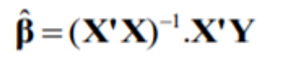

In [42]:
#ubah X dan Y menjadi bentuk matriks
X_new = np.array(X)
y_new = np.array(Y)

In [43]:
# transpose matriks X
XT = X_new.T

# menghitung (X'X)
XTX = np.dot(XT, X_new)
print(XTX)

[[7.80000000e+01 2.14424850e+03 1.80546250e+03 1.79790757e+02
  6.50601396e+01 1.55492695e+03]
 [2.14424850e+03 5.94274360e+04 5.02774317e+04 5.05425558e+03
  1.77827660e+03 4.35878932e+04]
 [1.80546250e+03 5.02774317e+04 4.31496296e+04 4.51094498e+03
  1.48366875e+03 3.73589982e+04]
 [1.79790757e+02 5.05425558e+03 4.51094498e+03 5.42997910e+02
  1.44491846e+02 3.90299900e+03]
 [6.50601396e+01 1.77827660e+03 1.48366875e+03 1.44491846e+02
  5.46697061e+01 1.27609842e+03]
 [1.55492695e+03 4.35878932e+04 3.73589982e+04 3.90299900e+03
  1.27609842e+03 3.27811317e+04]]


In [44]:
# menghitung invers (X'X)^(-1)
XTX_inv = np.linalg.inv(XTX)
print(XTX_inv)

[[ 6.36131158e+01 -3.40551778e-01 -1.02691605e+00  2.24748395e-01
  -4.57753156e+01  3.60919703e-01]
 [-3.40551778e-01  2.35673383e-02 -8.16596959e-03  2.49981883e-02
   9.61573562e-03 -9.22736828e-03]
 [-1.02691605e+00 -8.16596959e-03  2.94826823e-02 -2.69476063e-02
   8.51290123e-01 -3.96203868e-03]
 [ 2.24748395e-01  2.49981883e-02 -2.69476063e-02  5.81265222e-02
  -3.66726780e-01 -5.83379549e-03]
 [-4.57753156e+01  9.61573562e-03  8.51290123e-01 -3.66726780e-01
   3.60156915e+01 -1.70019645e-01]
 [ 3.60919703e-01 -9.22736828e-03 -3.96203868e-03 -5.83379549e-03
  -1.70019645e-01  7.00850310e-03]]


In [45]:
# menghitung X'Y
XTY =np.dot(XT,y_new)
print(XTY)

[ 1024.3635086  27665.00852832 23044.44051605  2245.87544903
   866.61962431 19614.23052433]


In [46]:
# menghitung beta
beta = np.dot(XTX_inv,XTY)

print("Koefisien beta:")
print(beta)

Koefisien beta:
[-8.98695964 -1.55012458  1.07638741 -0.88646884 46.43889629  0.15684299]


### **Interpretasikan model regresi dibawah ini terkait dengan**
*   Model Regresi
*   Menyelidiki Model
*   Uji Simultan
*   Uji Parsial
*   Koefisien Determinasi





In [47]:
# Membuat model regresi linear
model = sm.OLS(Y, X).fit()

# Melihat ringkasan model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     27.72
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.55e-15
Time:                        08:33:19   Log-Likelihood:                -164.19
No. Observations:                  78   AIC:                             340.4
Df Residuals:                      72   BIC:                             354.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.9870     16.485     -0.545      0.5

### **Interpretasikan Hasil running regresi berganda diatas**
*   Model Regresi
  
    Y=−8.987 − 1.550X1 ​+ 1.076X2 ​− 0.886X3 ​+ 46.439X4 ​+ 0.156X5​
    
    Model regresi yang diperoleh menunjukkan hubungan antara precipitation (curah hujan) dengan max temperature, min temperature, wind, relative humidity, dan solar.
  Artinya, perubahan pada variabel-variabel cuaca tersebut dapat mempengaruhi jumlah curah hujan.
*   Menyelidiki Model
   
    Dari hasil output regresi:

    R² = 0.658

    F-statistic = 27.72

    Prob(F) = 1.55e-15

    Dari hasil analisis terlihat bahwa beberapa variabel memiliki pengaruh yang lebih kuat terhadap precipitation, terutama relative humidity dan temperature. Variabel lain seperti wind dan solar pengaruhnya lebih kecil.
*   Uji Simultan

    Hasil:

    Prob(F-statistic) = 0.000

    Karena
    
    p-value < 0.05

    Hasil uji simultan menunjukkan bahwa semua variabel bebas secara bersama-sama berpengaruh terhadap precipitation. Jadi model regresi yang dibuat layak digunakan.
*   Uji Parsial
  
    Dilihat dari nilai P>|t|

    Hasil uji parsial menunjukkan bahwa:

    * Max temperature(X1), min temperature(X2), dan relative humidity(X4) berpengaruh signifikan terhadap precipitation.

    * Wind(X3) dan solar(X5) tidak berpengaruh signifikan terhadap precipitation.
*   Koefisien Determinasi

    Nilai koefisien determinasi pada model regresi adalah R² = 0.658.
    
    Berarti 65,8% variasi precipitation dapat dijelaskan oleh variabel max temperature (X1), min temperature (X2), wind (X3), relative humidity (X4), dan solar (X5) dalam model regresi. Sedangkan 34,2% sisanya dipengaruhi oleh faktor lain di luar model yang tidak dimasukkan dalam penelitian.


**3. Menyelidiki Asumsi Model Regresi**


3.a. Asumsi Normalitas

Data dikatakan terdistribusi normal jika kurva berbentuk normal

UJi shapiro, jika p-value > 0.05: data terdistribusi normal

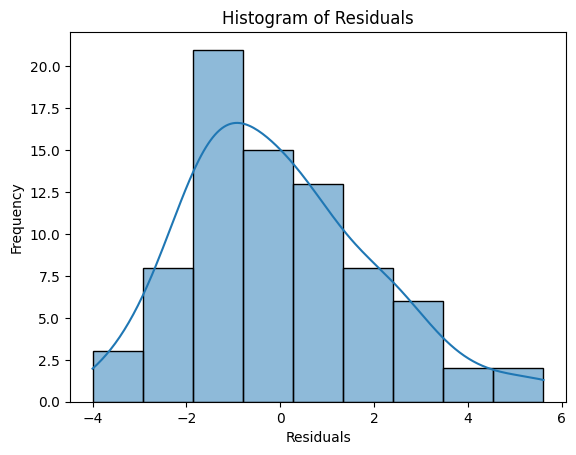

Shapiro-Wilk Test: W=0.9658793950238578, p-value=0.034639058388638753


In [48]:
# Plot Histogram Residual
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test[1]}')

# Interpretasi
Histogram residual digunakan untuk melihat apakah data residual membentuk kurva normal. Jika bentuknya menyerupai kurva lonceng (bell shape) maka data cenderung normal.

* Hasil uji Shapiro-Wilk menunjukkan p-value = 0.0346.
* Karena p-value < 0.05, maka residual tidak berdistribusi normal.

Kesimpulan:
Asumsi normalitas belum terpenuhi, sehingga perlu dilakukan transformasi data agar distribusi residual menjadi lebih normal.

### **Cara menormalkannya, bisa dengan cara transformasi.**

In [49]:
#transformasi ln
# Membuat model regresi linear
model_ln = sm.OLS(np.log(Y), X).fit()

# Melihat ringkasan model
print(model_ln.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     26.32
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           5.10e-15
Time:                        08:33:19   Log-Likelihood:                 41.143
No. Observations:                  78   AIC:                            -70.29
Df Residuals:                      72   BIC:                            -56.15
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7160      1.185      0.604      0.5

# Interpretasi
Setelah dilakukan transformasi ln pada variabel precipitation, model regresi menunjukkan bahwa:

* Max temperature (X1), min temperature (X2), dan relative humidity (X4) berpengaruh signifikan terhadap precipitation karena p-value < 0.05.
* Wind (X3) dan solar (X5) tidak berpengaruh signifikan terhadap precipitation karena p-value > 0.05.

Nilai R² sekitar 0.64, artinya sekitar 64% variasi precipitation dapat dijelaskan oleh variabel dalam model, sedangkan 36% dipengaruhi oleh faktor lain di luar model.

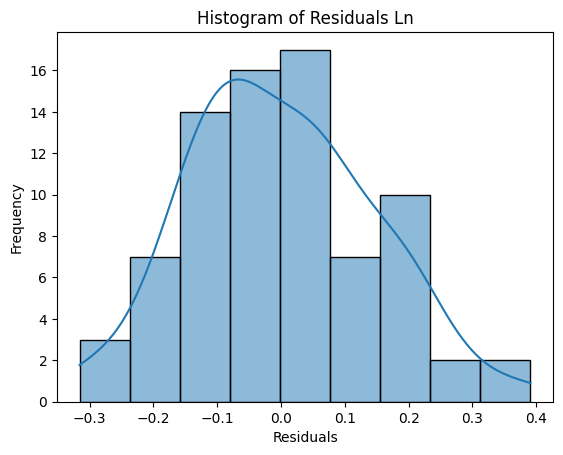

Shapiro-Wilk Test: W=0.9658793950238578, p-value=0.6675319920299785


In [50]:
# Plot Histogram Residual
residuals_ln = model_ln.resid
sns.histplot(residuals_ln, kde=True)
plt.title('Histogram of Residuals Ln')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test_ln = stats.shapiro(residuals_ln)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test_ln[1]}')

# Interpretasi
Histogram residual setelah dilakukan transformasi ln menunjukkan bahwa distribusi residual mendekati bentuk kurva normal.
Hasil uji Shapiro-Wilk menunjukkan nilai p-value = 0.6675.
Karena p-value > 0.05, maka residual berdistribusi normal.

3.b. Asumsi Heteroskedastisitas

Jika p-value < 0.05 : terjadi heteroskedastisitas

Harapannya adalah tidak terjadi heteroskedastisitas

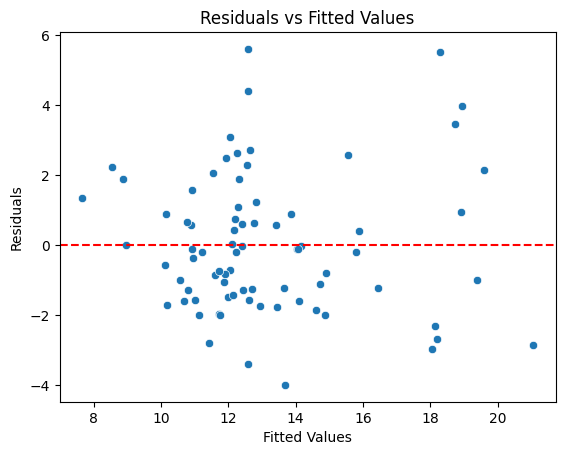

Breusch-Pagan Test: p-value=0.029179650329912744


In [51]:
# Plot Residual vs Fitted Values
fitted_values = model.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Uji Homoskedastisitas menggunakan Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X)
print(f'Breusch-Pagan Test: p-value={bp_test[1]}')

# Interpretasi:
* Grafik Residuals vs Fitted Values digunakan untuk melihat
apakah terdapat pola tertentu pada residual. Jika titik-titik menyebar secara acak di sekitar garis nol, maka model tidak mengalami heteroskedastisitas.
* Berdasarkan uji Breusch-Pagan, diperoleh p-value = 0.029.
* Karena p-value < 0.05, maka terjadi heteroskedastisitas pada model.

Kesimpulan:
Asumsi homoskedastisitas tidak terpenuhi, karena terdapat heteroskedastisitas pada residual model. Artinya varians error tidak konstan.

3.c. Asumsi Autokorelasi

p-value < 0.05 menunjukkan adanya autokorelasi yang signifikan secara statistik.

p-value >= 0.05 menunjukkan tidak ada autokorelasi yang signifikan.

In [52]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson

# Melakukan Uji Breusch-Godfrey untuk Autokorelasi
dw_test = durbin_watson(residuals)
bg_test = acorr_breusch_godfrey(model, nlags=1)
p_value = bg_test[1]  # Mendapatkan p-value



print(f'Breusch-Pagan Value: {dw_test}')
print(f'Breusch-Godfrey p-value: {p_value}')

Breusch-Pagan Value: 1.7830776392551193
Breusch-Godfrey p-value: 0.4891952292600158


# Interpretasi
* Hasil uji autokorelasi menggunakan Breusch-Godfrey menunjukkan nilai p-value = 0.489.
* Karena p-value ≥ 0.05, maka tidak terdapat autokorelasi yang signifikan pada model.
* Nilai Durbin-Watson = 1.78 juga mendekati angka 2, yang menunjukkan bahwa tidak ada masalah autokorelasi pada residual.

Kesimpulan:
Model regresi tidak mengalami autokorelasi, sehingga asumsi autokorelasi terpenuhi.

3.d. Asumsi Multikolinieritas

vif<10: tidak terjadi multiko

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF (Variance Inflation Factor)
VIF = pd.DataFrame()
VIF["variables"] = X.columns
VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(VIF)

  variables          VIF
0     const  4961.823030
1        X1    11.342047
2        X2    40.057239
3        X3     7.473819
4        X4    14.505695
5        X5    12.501233


# Interpretasi
* Uji multikolinieritas dilakukan menggunakan nilai Variance Inflation Factor (VIF).
* Jika nilai VIF < 10 maka tidak terjadi multikolinieritas, sedangkan jika VIF ≥ 10 maka terjadi multikolinieritas.

Berdasarkan hasil perhitungan, beberapa variabel memiliki nilai VIF lebih dari 10, yaitu max temperature (X1), min temperature (X2), relative humidity (X4), dan solar (X5).

Kesimpulan:
Ini menunjukkan bahwa terdapat multikolinieritas pada model regresi, yang berarti beberapa variabel independen memiliki hubungan yang cukup kuat satu sama lain. Namun variabel wind (X3) tidak mengalami multikolinieritas karena nilai VIF kurang dari 10.